
==================== RUN 1 - SINGLE MODE ====================

[1] Label Distribution (Top 3 per model)
------------------------------------------------------------
gpt-5.2             : {'J': 33, 'N': 15, 'I': 15}
claude-sonnet-4.5   : {'J': 33, 'N': 17, 'B': 10}
gemini-2.5-flash    : {'J': 42, 'N': 20, 'I': 15}
deepseek-v3.2       : {'J': 44, 'D': 20, 'N': 15}
qwen3-coder         : {'J': 34, 'N': 23, 'D': 23}
gpt-oss-120b        : {'I': 19, 'N': 19, 'J': 14}

[2] Consensus Analysis
------------------------------------------------------------
Consensus Questions:    18
Disagreement Questions: 82
Consensus Rate:         18.0%

[3] Variance Analysis (Unique labels per row)
------------------------------------------------------------
1 Different Labels:    18 rows
2 Different Labels:    38 rows
3 Different Labels:    24 rows
4 Different Labels:    16 rows
5 Different Labels:    4 rows

[4] Group Agreement Rates
------------------------------------------------------------
Closed Models A

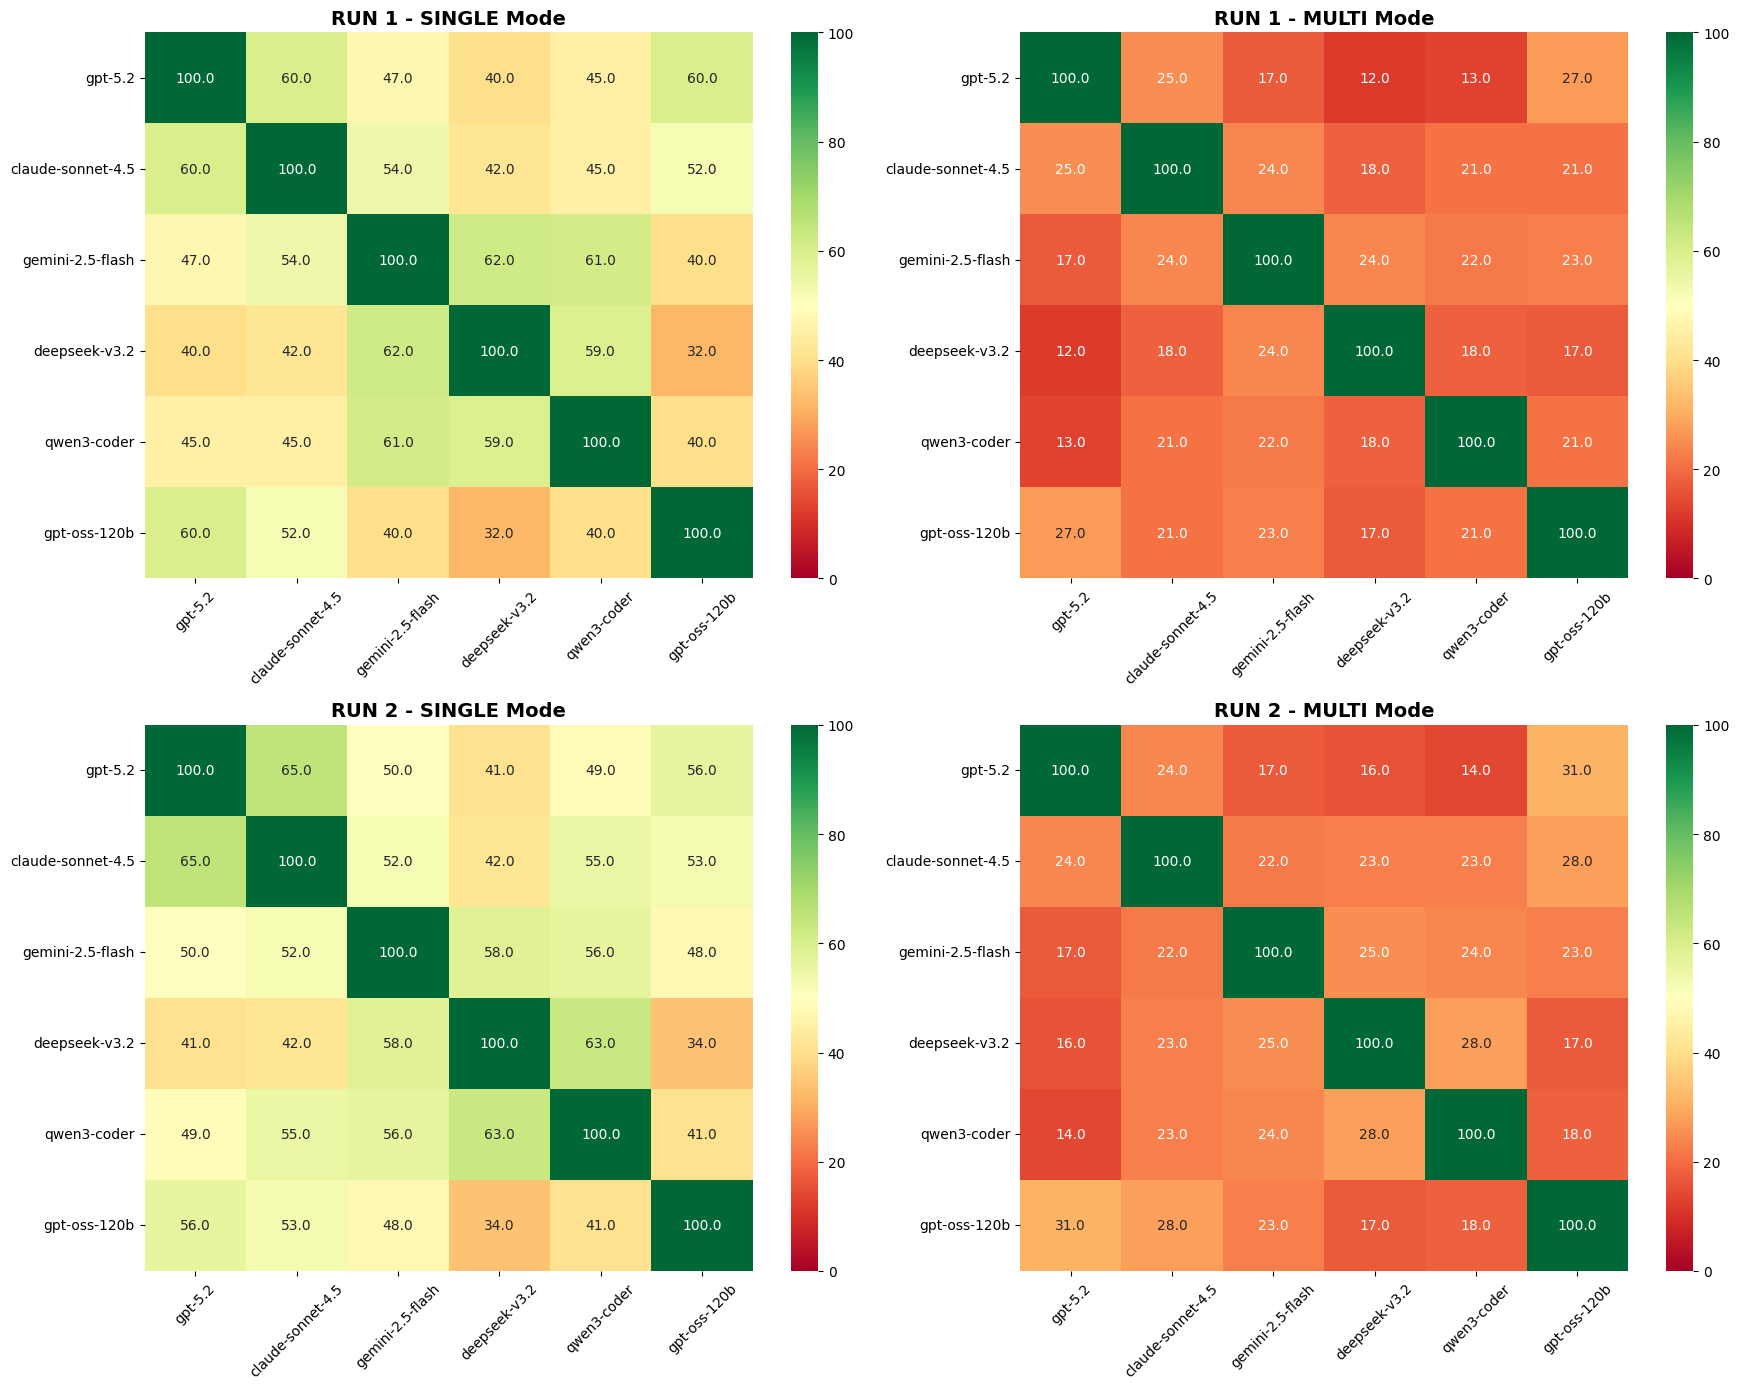

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. HELPER FUNCTIONS ---
def clean_labels(val):
    """
    Converts inputs like 'A,B', 'None', 'nan' into sets like {'A', 'B'} or {'N'}.
    """
    val_str = str(val).strip().upper()

    # Handle explicit None/NaN/Empty
    if pd.isna(val) or val_str in ['NAN', 'NONE', '']:
        return {'N'}

    # Split by comma or treat as sequence
    if ',' in val_str:
        tokens = [t.strip() for t in val_str.split(',')]
    else:
        tokens = list(val_str)

    # Filter alphanumeric only
    valid_tokens = {t for t in tokens if t.isalnum()}

    return valid_tokens if valid_tokens else {'N'}

def calculate_metrics(pred_set, gt_set):
    """
    Returns a dictionary of values for the 4 cases.
    """
    # Special check: If both are N, it counts as success for all cases
    if pred_set == {'N'} and gt_set == {'N'}:
        return {'A': 1, 'B': 1, 'C': 1, 'D': 1.0}

    # Intersection & Union
    intersection = pred_set.intersection(gt_set)
    union = pred_set.union(gt_set)

    # Case A: Pred is subset of GT (Precision) - "Did I say anything wrong?"
    case_a = 1 if pred_set.issubset(gt_set) else 0

    # Case B: GT is subset of Pred (Recall) - "Did I miss anything?"
    case_b = 1 if gt_set.issubset(pred_set) else 0

    # Case C: Overlap - "Did I get at least one thing right?"
    case_c = 1 if len(intersection) > 0 else 0

    # Case D: Jaccard Score
    case_d = len(intersection) / len(union) if len(union) > 0 else 0.0

    return {'A': case_a, 'B': case_b, 'C': case_c, 'D': case_d}

# --- 2. DATA LOADING & PREP ---
try:
    single_df = pd.read_csv('yaksh_single.csv')
    multi_df = pd.read_csv('yaksh_multi.csv')
    ground_df = pd.read_csv('ground.csv')
except FileNotFoundError:
    print("Files not found. Generating Dummy Data for demonstration...")
    # Dummy Data Generation (for testing without files)
    models_base = ['gpt-5.2', 'claude-sonnet-4.5', 'gemini-2.5-flash', 'deepseek-v3.2', 'qwen3-coder', 'gpt-oss-120b']
    cols = []
    for m in models_base:
        cols.extend([m, f"Unnamed_{m}"]) # Simulating the empty column issue

    single_df = pd.DataFrame(np.random.choice(list('ABCDEJ'), size=(100, 12)), columns=cols)
    single_df['Sr. no.'] = range(1, 101)
    multi_df = pd.DataFrame(np.random.choice(['A', 'AB', 'C', 'J', 'JE'], size=(100, 12)), columns=cols)
    multi_df['Sr. no.'] = range(1, 101)
    ground_df = pd.DataFrame({'Sr. no.': range(1, 101), 'ground_error': np.random.choice(['A,B', 'J', 'None'], size=100)})

# Standardize Columns
single_df.rename(columns=lambda x: x.strip(), inplace=True)
multi_df.rename(columns=lambda x: x.strip(), inplace=True)
ground_df.rename(columns=lambda x: x.strip(), inplace=True)

# Merge Ground Truth
ground_df['cleaned_gt_set'] = ground_df['ground_error'].apply(clean_labels)

if 'cleaned_gt_set' not in single_df.columns:
    single_df = single_df.merge(ground_df[['Sr. no.', 'cleaned_gt_set']], on='Sr. no.', how='left')
if 'cleaned_gt_set' not in multi_df.columns:
    multi_df = multi_df.merge(ground_df[['Sr. no.', 'cleaned_gt_set']], on='Sr. no.', how='left')

# Define Model Groups
models_base = ['gpt-5.2', 'claude-sonnet-4.5', 'gemini-2.5-flash', 'deepseek-v3.2', 'qwen3-coder', 'gpt-oss-120b']
closed_models = ['gpt-5.2', 'claude-sonnet-4.5', 'gemini-2.5-flash']
open_models = ['deepseek-v3.2', 'qwen3-coder', 'gpt-oss-120b']

def get_run_columns(df, run_idx):
    """
    Robust column extractor.
    run_idx 0 = Run 1 (Model Name)
    run_idx 1 = Run 2 (Model Name + 1 index, often unnamed)
    """
    col_map = {}
    for m in models_base:
        try:
            # Find the index of the base model column
            loc = df.columns.get_loc(m)

            # If get_loc returns a slice/array (duplicates), take the first one
            if isinstance(loc, (slice, np.ndarray)):
                loc = loc.start if isinstance(loc, slice) else loc[0]

            target_idx = loc + run_idx

            if target_idx < len(df.columns):
                col_map[m] = df.columns[target_idx]
            else:
                col_map[m] = df.columns[loc] # Fallback
        except KeyError:
            pass # Model not found

    return col_map

# --- 3. ANALYSIS ENGINE ---
def analyze_scenario(df, mode_name, run_name, run_idx):
    print(f"\n{'='*20} {run_name} - {mode_name} MODE {'='*20}")

    col_map = get_run_columns(df, run_idx)
    current_cols = list(col_map.values())

    # [1] LABEL DISTRIBUTION
    print(f"\n[1] Label Distribution (Top 3 per model)")
    print("-" * 60)
    for m, col in col_map.items():
        dist = df[col].value_counts().head(3).to_dict()
        print(f"{m:<20}: {dist}")

    # [2] CONSENSUS ANALYSIS
    consensus_mask = df[current_cols].nunique(axis=1) == 1
    consensus_count = consensus_mask.sum()
    print(f"\n[2] Consensus Analysis")
    print("-" * 60)
    print(f"Consensus Questions:    {consensus_count}")
    print(f"Disagreement Questions: {len(df) - consensus_count}")
    print(f"Consensus Rate:         {(consensus_count/len(df))*100:.1f}%")

    # [3] VARIANCE ANALYSIS
    variance_counts = df[current_cols].nunique(axis=1).value_counts().sort_index()
    print(f"\n[3] Variance Analysis (Unique labels per row)")
    print("-" * 60)
    for k, v in variance_counts.items():
        print(f"{k} Different Labels:    {v} rows")

    # [4] GROUP AGREEMENT
    closed_cols = [col_map.get(m) for m in closed_models if m in col_map]
    open_cols = [col_map.get(m) for m in open_models if m in col_map]

    if closed_cols:
        closed_agree = (df[closed_cols].nunique(axis=1) == 1).sum()
        print(f"\n[4] Group Agreement Rates")
        print("-" * 60)
        print(f"Closed Models Agreement: {closed_agree} rows ({(closed_agree/len(df))*100:.1f}%)")

    if open_cols:
        open_agree = (df[open_cols].nunique(axis=1) == 1).sum()
        print(f"Open Models Agreement:   {open_agree} rows ({(open_agree/len(df))*100:.1f}%)")

    # [5] PAIRWISE AGREEMENT MATRIX (Returns matrix for plotting)
    matrix = pd.DataFrame(index=models_base, columns=models_base, dtype=float)
    for m1 in models_base:
        for m2 in models_base:
            if m1 in col_map and m2 in col_map:
                c1 = col_map[m1]
                c2 = col_map[m2]
                agree = (df[c1] == df[c2]).mean() * 100
                matrix.loc[m1, m2] = agree
            else:
                matrix.loc[m1, m2] = 0.0

    # [6] ACCURACY ANALYSIS (4 Cases)
    print(f"\n[6] Accuracy Analysis (vs Ground Truth)")
    print("-" * 115)
    headers = f"{'Model':<20} | {'Case A (SubSet)':<15} | {'Case B (SuperSet)':<18} | {'Case C (Overlap)':<18} | {'Case D (Jaccard)':<18}"
    print(headers)
    print("-" * 115)

    for m, col in col_map.items():
        stats = {'A': 0, 'B': 0, 'C': 0, 'D': []}

        for i, row in df.iterrows():
            pred = clean_labels(row[col])
            gt = row['cleaned_gt_set']
            if not isinstance(gt, set): gt = {'N'} # Safety

            metrics = calculate_metrics(pred, gt)
            stats['A'] += metrics['A']
            stats['B'] += metrics['B']
            stats['C'] += metrics['C']
            stats['D'].append(metrics['D'])

        n = len(df)
        res_str = (
            f"{m:<20} | "
            f"{(stats['A']/n)*100:<15.1f} | "
            f"{(stats['B']/n)*100:<18.1f} | "
            f"{(stats['C']/n)*100:<18.1f} | "
            f"{np.mean(stats['D'])*100:<18.1f}"
        )
        print(res_str)

    return matrix

# --- 4. EXECUTION & VISUALIZATION ---
scenarios = [
    (single_df, "SINGLE", "RUN 1", 0),
    (multi_df,  "MULTI",  "RUN 1", 0),
    (single_df, "SINGLE", "RUN 2", 1),
    (multi_df,  "MULTI",  "RUN 2", 1)
]

matrices = []
titles = []

for df_obj, mode, run, idx in scenarios:
    mat = analyze_scenario(df_obj, mode, run, idx)
    matrices.append(mat)
    titles.append(f"{run} - {mode} Mode")

# Plotting the 4 Heatmaps (Pairwise Agreement)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, ax in enumerate(axes):
    sns.heatmap(matrices[i], annot=True, fmt=".1f", cmap="RdYlGn", vmin=0, vmax=100, ax=ax)
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

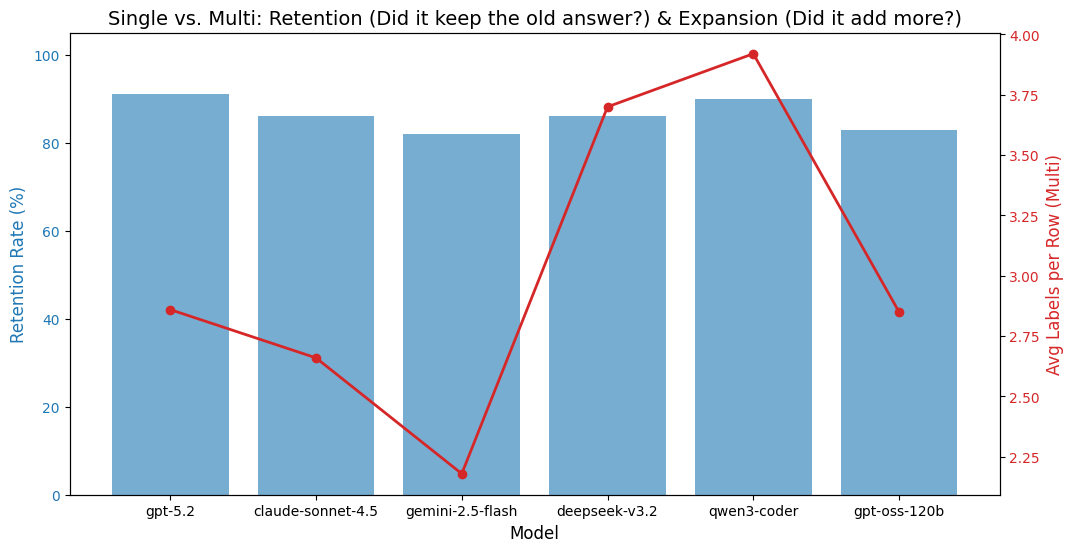

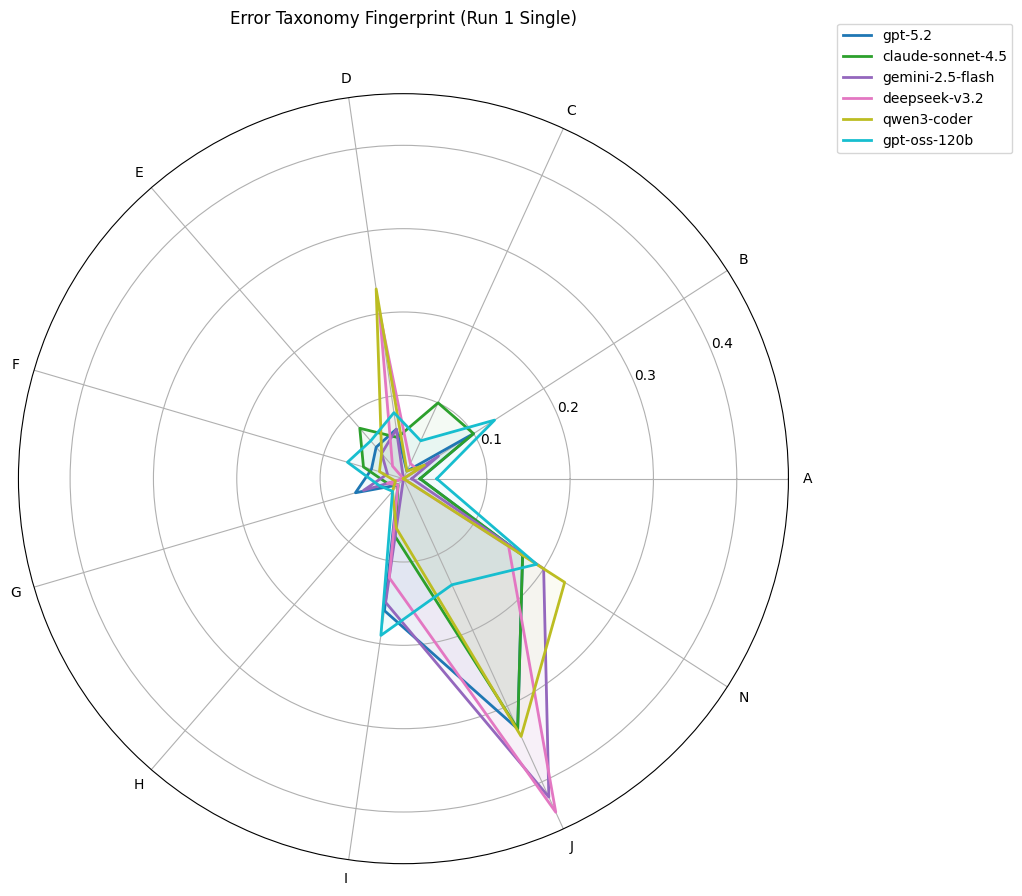


TOP 5 DISPUTED SAMPLES (High Disagreement)
------------------------------------------------------------
Row 28 | Chaos Score: 5/6
Question: 1. Create a <code>LinearEquation</code> class in two variables which takes three components and supp...
Votes:
  gpt-5.2: {'I'}
  claude-sonnet-4.5: {'C'}
  gemini-2.5-flash: {'D'}
  deepseek-v3.2: {'J'}
  qwen3-coder: {'B'}
  gpt-oss-120b: {'B'}
------------------------------------------------------------
Row 47 | Chaos Score: 5/6
Question: Write a function <code>is_palindrome(arg)</code> which will take one string argument. <br> Return Tr...
Votes:
  gpt-5.2: {'B'}
  claude-sonnet-4.5: {'E'}
  gemini-2.5-flash: {'J'}
  deepseek-v3.2: {'J'}
  qwen3-coder: {'N'}
  gpt-oss-120b: {'I'}
------------------------------------------------------------
Row 93 | Chaos Score: 5/6
Question: <p>Write a function <code>word_frequency(s,n)</code> to find the most frequently occurring words in ...
Votes:
  gpt-5.2: {'J'}
  claude-sonnet-4.5: {'C'}
  gemini-2.5-fla

In [6]:
# A. SINGLE VS MULTI: RETENTION & EXPANSION
# Compares Run 1 Single vs Run 1 Multi
comparison_stats = []
run_idx = 0

# Get Run 1 columns for both dataframes
single_cols = get_run_columns(single_df, run_idx)
multi_cols = get_run_columns(multi_df, run_idx)

for m in models_base:
    if m not in single_cols or m not in multi_cols: continue

    s_col = single_cols[m]
    m_col = multi_cols[m]

    contained_count = 0
    total_labels_multi = 0
    rows = len(single_df)

    for i in range(rows):
        s_val = clean_labels(single_df.iloc[i][s_col])
        m_val = clean_labels(multi_df.iloc[i][m_col])

        # Retention: Is the single label (s_val) present inside the multi set (m_val)?
        # If Single said "N" (None), and Multi said "N", that counts as retention.
        if s_val.issubset(m_val):
            contained_count += 1

        # Expansion: How many labels did it spit out in Multi?
        # If 'N', count is 0 for error counting purposes, or 1?
        # Usually 'N' means 0 errors found. Let's count size of set, but treat 'N' as 0 errors.
        if m_val == {'N'}:
            total_labels_multi += 0
        else:
            total_labels_multi += len(m_val)

    comparison_stats.append({
        'Model': m,
        'Avg_Labels_Per_Row': total_labels_multi / rows,
        'Retention_Rate': (contained_count / rows) * 100
    })

comp_df = pd.DataFrame(comparison_stats)

# Plot Retention vs Expansion
fig, ax1 = plt.subplots(figsize=(12, 6))
color = 'tab:blue'
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Retention Rate (%)', color=color, fontsize=12)
ax1.bar(comp_df['Model'], comp_df['Retention_Rate'], color=color, alpha=0.6, label='Retention')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 105)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Avg Labels per Row (Multi)', color=color, fontsize=12)
ax2.plot(comp_df['Model'], comp_df['Avg_Labels_Per_Row'], color=color, marker='o', linewidth=2, label='Expansion')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Single vs. Multi: Retention (Did it keep the old answer?) & Expansion (Did it add more?)', fontsize=14)
plt.show()

# B. RADAR CHART (Bias Analysis)
from math import pi

# Define categories (Standard Error Codes + N)
categories = sorted(list('ABCDEFGHIJN'))
N_CAT = len(categories)

# Setup Radar Plot
angles = [n / float(N_CAT) * 2 * pi for n in range(N_CAT)]
angles += angles[:1] # Close the loop

plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

# Helper to get distribution for a model
def get_error_distribution(df, col_name):
    # Flatten all sets into a single list of characters
    all_chars = []
    for val in df[col_name]:
        cleaned = clean_labels(val)
        all_chars.extend(list(cleaned))

    # Count frequency
    counts = pd.Series(all_chars).value_counts()
    # Normalize to 0-1 scale relative to total rows (propensity)
    return [counts.get(cat, 0) / len(df) for cat in categories]

# Plot each model (Run 1 Single Mode)
colors = plt.cm.tab10(np.linspace(0, 1, len(models_base)))

for idx, m in enumerate(models_base):
    if m in single_cols:
        values = get_error_distribution(single_df, single_cols[m])
        values += values[:1] # Close loop
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=m, color=colors[idx])
        ax.fill(angles, values, color=colors[idx], alpha=0.05)

plt.xticks(angles[:-1], categories)
plt.title('Error Taxonomy Fingerprint (Run 1 Single)', y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

# C. CHAOS SCORE (Disagreement Analysis)
# How many unique answers exist per row across all 6 models?
chaos_cols = list(single_cols.values())

def get_chaos_score(row):
    # Collect the sets from all models
    answers = [str(clean_labels(row[c])) for c in chaos_cols]
    return len(set(answers)) # Count unique sets

single_df['chaos_score'] = single_df.apply(get_chaos_score, axis=1)

print("\nTOP 5 DISPUTED SAMPLES (High Disagreement)")
print("-" * 60)
top_chaos = single_df.nlargest(5, 'chaos_score')

for idx, row in top_chaos.iterrows():
    print(f"Row {row['Sr. no.']} | Chaos Score: {row['chaos_score']}/6")
    # Truncate question text if it exists
    q_text = str(row.get('question__description', 'No Question Text'))[:100].replace('\n', ' ')
    print(f"Question: {q_text}...")
    print("Votes:")
    for m, col in single_cols.items():
        print(f"  {m}: {clean_labels(row[col])}")
    print("-" * 60)